In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px

In [7]:
file_path = 'flights.csv'
df = pd.read_csv(file_path)

In [8]:
print("\nFirst 5 Rows:\n")
print(df.head())


First 5 Rows:

   DayofMonth  DayOfWeek Carrier  OriginAirportID  DestAirportID  DepDelay  \
0          19          5      DL            11433          13303        -3   
1          19          5      DL            14869          12478         0   
2          19          5      DL            14057          14869        -4   
3          19          5      DL            15016          11433        28   
4          19          5      DL            11193          12892        -6   

   ArrDelay  
0         1  
1        -8  
2       -15  
3        24  
4       -11  


In [9]:
print("\nFirst 5 Rows:\n")
print(df.head())


First 5 Rows:

   DayofMonth  DayOfWeek Carrier  OriginAirportID  DestAirportID  DepDelay  \
0          19          5      DL            11433          13303        -3   
1          19          5      DL            14869          12478         0   
2          19          5      DL            14057          14869        -4   
3          19          5      DL            15016          11433        28   
4          19          5      DL            11193          12892        -6   

   ArrDelay  
0         1  
1        -8  
2       -15  
3        24  
4       -11  


In [10]:
print("\nDataset Information:\n")
print(df.info())


Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2702218 entries, 0 to 2702217
Data columns (total 7 columns):
 #   Column           Dtype 
---  ------           ----- 
 0   DayofMonth       int64 
 1   DayOfWeek        int64 
 2   Carrier          object
 3   OriginAirportID  int64 
 4   DestAirportID    int64 
 5   DepDelay         int64 
 6   ArrDelay         int64 
dtypes: int64(6), object(1)
memory usage: 144.3+ MB
None


In [11]:
print("\nMissing Values:\n")
print(df.isnull().sum())



Missing Values:

DayofMonth         0
DayOfWeek          0
Carrier            0
OriginAirportID    0
DestAirportID      0
DepDelay           0
ArrDelay           0
dtype: int64


In [12]:
print("\nStatistical Summary:\n")
print(df.describe())


Statistical Summary:

         DayofMonth     DayOfWeek  OriginAirportID  DestAirportID  \
count  2.702218e+06  2.702218e+06     2.702218e+06   2.702218e+06   
mean   1.579790e+01  3.899480e+00     1.274260e+04   1.274300e+04   
std    8.798835e+00  1.985925e+00     1.501841e+03   1.501801e+03   
min    1.000000e+00  1.000000e+00     1.014000e+04   1.014000e+04   
25%    8.000000e+00  2.000000e+00     1.129200e+04   1.129200e+04   
50%    1.600000e+01  4.000000e+00     1.289200e+04   1.289200e+04   
75%    2.300000e+01  6.000000e+00     1.405700e+04   1.405700e+04   
max    3.100000e+01  7.000000e+00     1.537600e+04   1.537600e+04   

           DepDelay      ArrDelay  
count  2.702218e+06  2.702218e+06  
mean   1.051073e+01  6.655011e+00  
std    3.602976e+01  3.854758e+01  
min   -6.300000e+01 -9.400000e+01  
25%   -4.000000e+00 -1.100000e+01  
50%   -1.000000e+00 -3.000000e+00  
75%    9.000000e+00  1.000000e+01  
max    1.863000e+03  1.845000e+03  


In [13]:
# Remove duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)


Duplicate Rows: 5561


In [14]:
# =========================
# DATA VISUALIZATION
# =========================

In [15]:
sns.set_style('whitegrid')


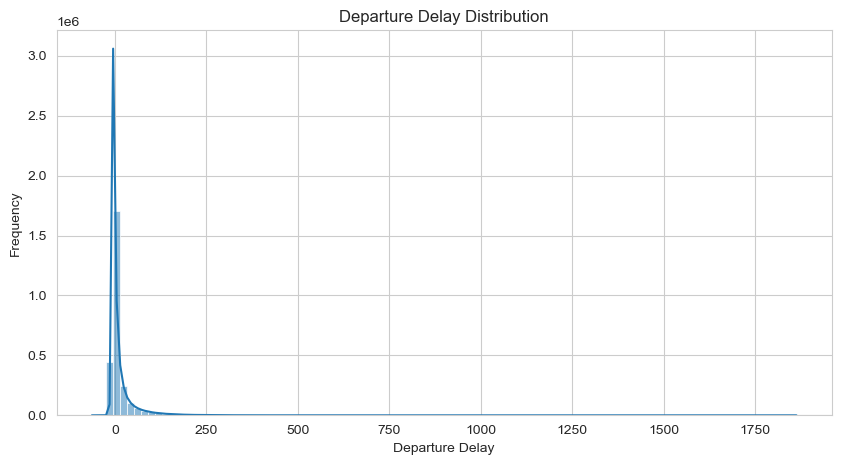

In [19]:
# 1. Departure Delay Distribution
plt.figure(figsize=(10,5))
sns.histplot(df['DepDelay'], bins=100, kde=True)
plt.title("Departure Delay Distribution")
plt.xlabel("Departure Delay")
plt.ylabel("Frequency")
plt.show()

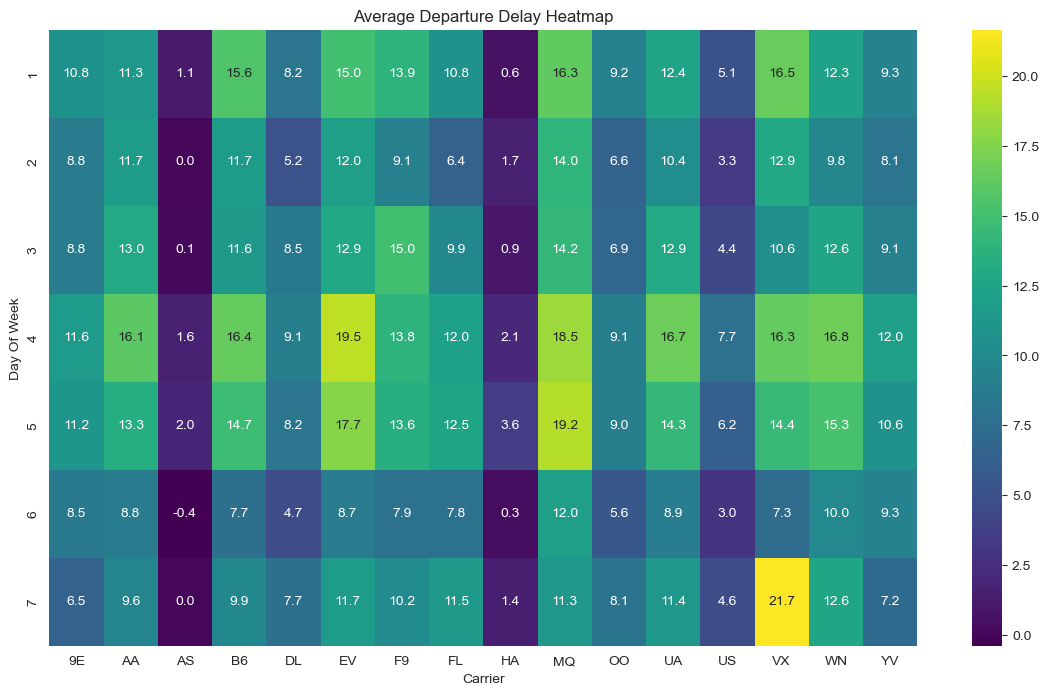

In [20]:
# HEATMAP : DayOfWeek vs Average Departure Delay

pivot_df = df.pivot_table(
    values='DepDelay',
    index='DayOfWeek',
    columns='Carrier',
    aggfunc='mean'
)

plt.figure(figsize=(14,8))

sns.heatmap(
    pivot_df,
    cmap='viridis',
    annot=True,
    fmt='.1f'
)

plt.title('Average Departure Delay Heatmap')
plt.xlabel('Carrier')
plt.ylabel('Day Of Week')

plt.show()

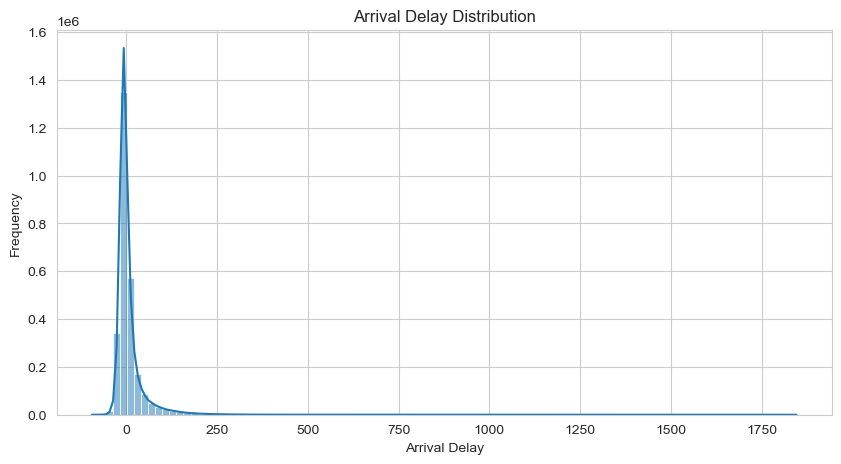

In [21]:
# 2. Arrival Delay Distribution
plt.figure(figsize=(10,5))
sns.histplot(df['ArrDelay'], bins=100, kde=True)
plt.title("Arrival Delay Distribution")
plt.xlabel("Arrival Delay")
plt.ylabel("Frequency")
plt.show()


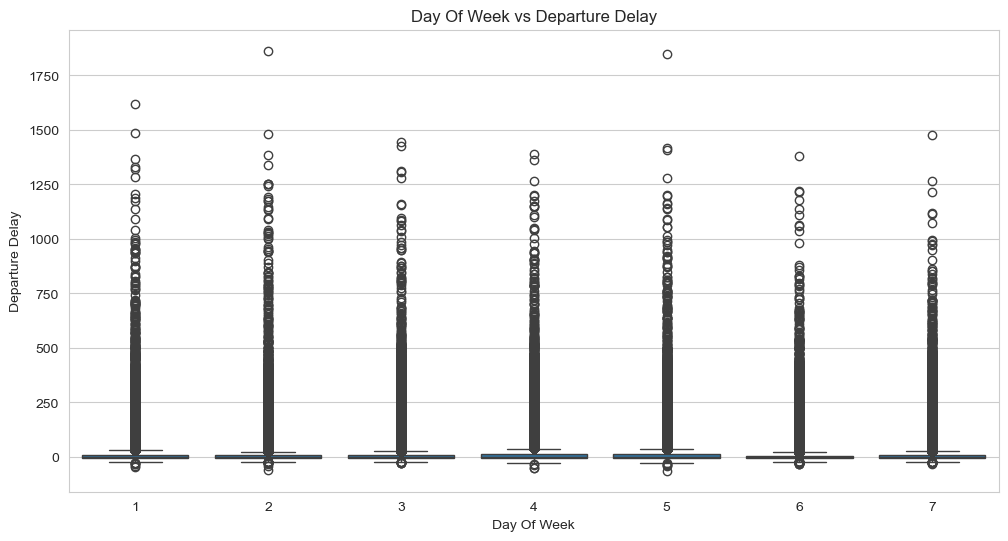

In [24]:
# 3. DAY OF WEEK VS DEPARTURE DELAY

plt.figure(figsize=(12,6))

sns.boxplot(
    x='DayOfWeek',
    y='DepDelay',
    data=df
)

plt.title('Day Of Week vs Departure Delay')
plt.xlabel('Day Of Week')
plt.ylabel('Departure Delay')

plt.show()

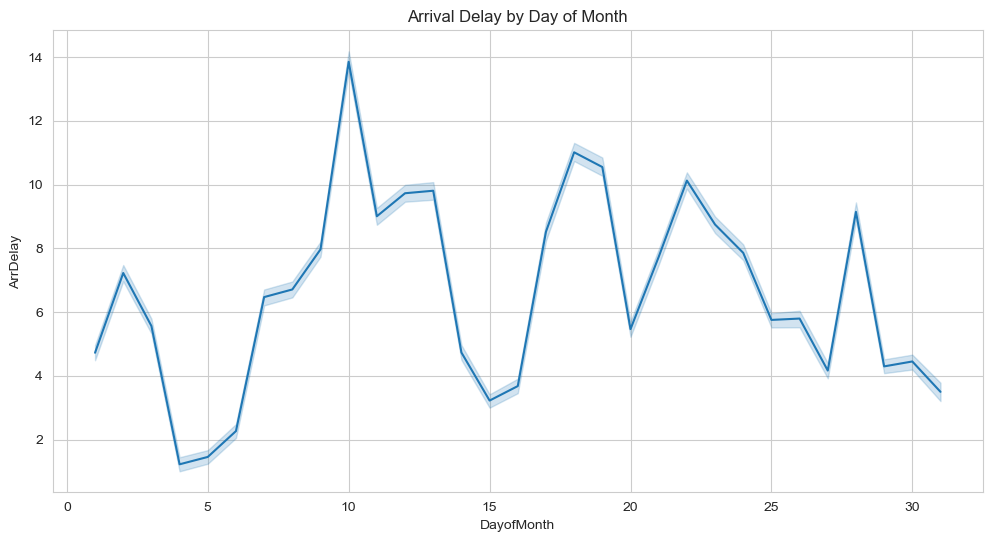

In [27]:
# 5. Day of Month vs Arrival Delay


plt.figure(figsize=(12,6))
sns.lineplot(x='DayofMonth', y='ArrDelay', data=df)
plt.title("Arrival Delay by Day of Month")
plt.show()

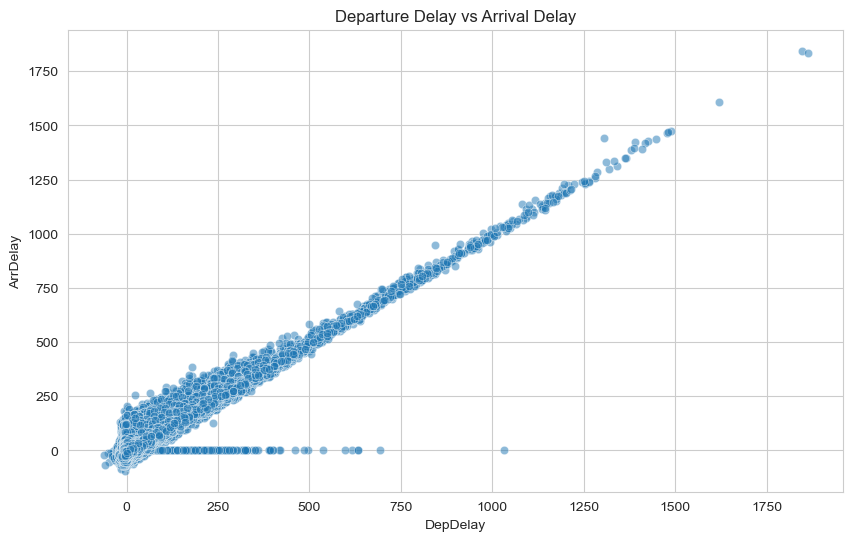

In [28]:
# 6. Scatter Plot
plt.figure(figsize=(10,6))
sns.scatterplot(x='DepDelay', y='ArrDelay', alpha=0.5, data=df)
plt.title("Departure Delay vs Arrival Delay")
plt.show()

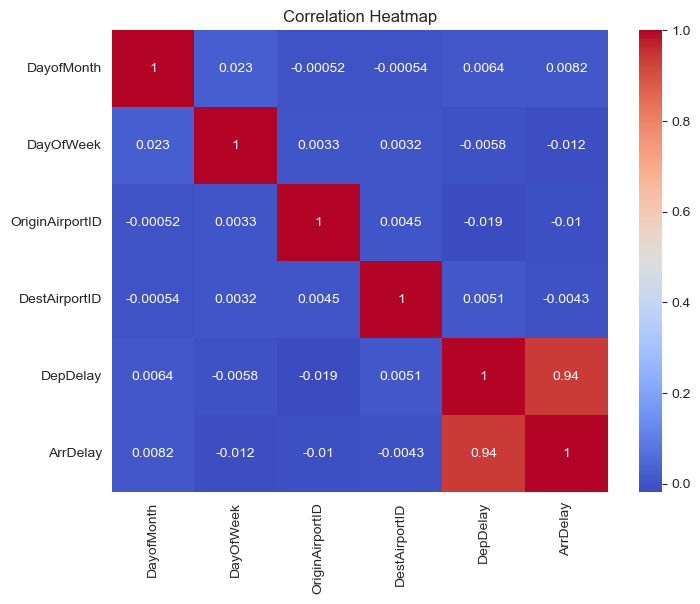

In [29]:
# 7. Heatmap Correlation
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


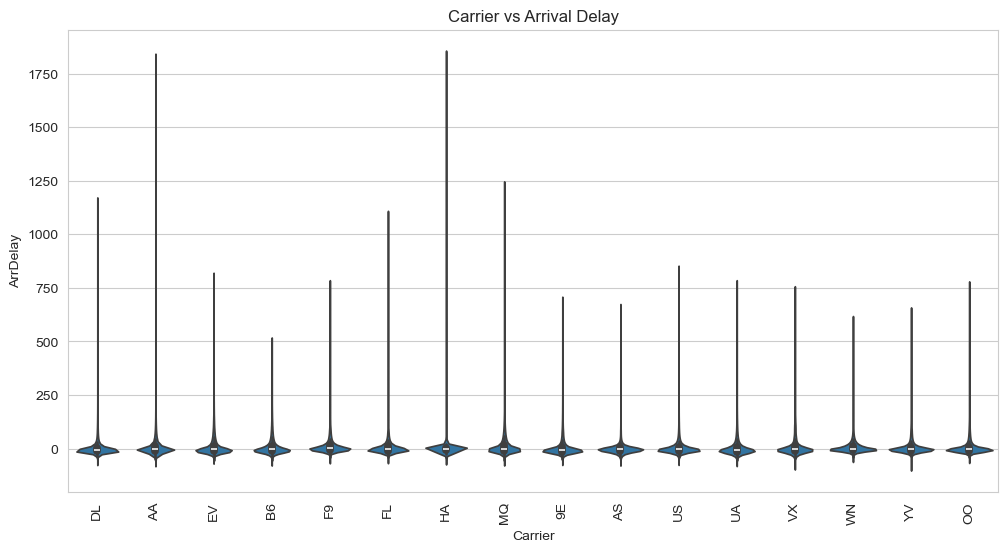

In [30]:
# 8. Violin Plot
plt.figure(figsize=(12,6))
sns.violinplot(x='Carrier', y='ArrDelay', data=df)
plt.title("Carrier vs Arrival Delay")
plt.xticks(rotation=90)
plt.show()

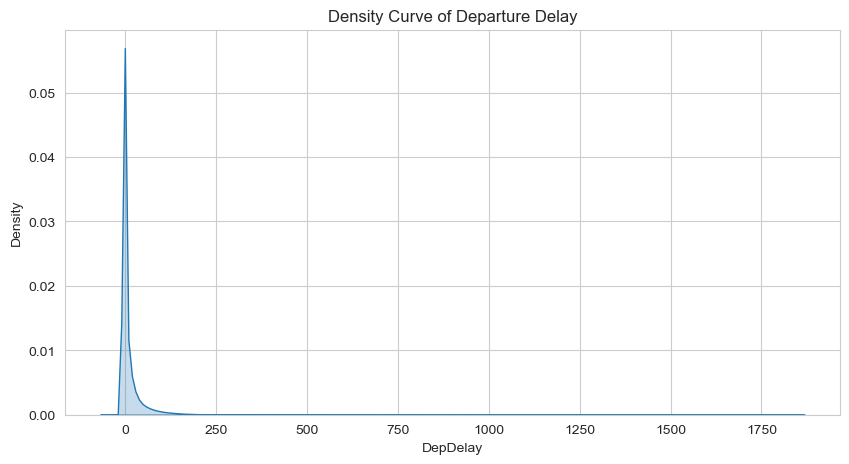

In [31]:
# 9. KDE Plot
plt.figure(figsize=(10,5))
sns.kdeplot(df['DepDelay'], fill=True)
plt.title("Density Curve of Departure Delay")
plt.show()

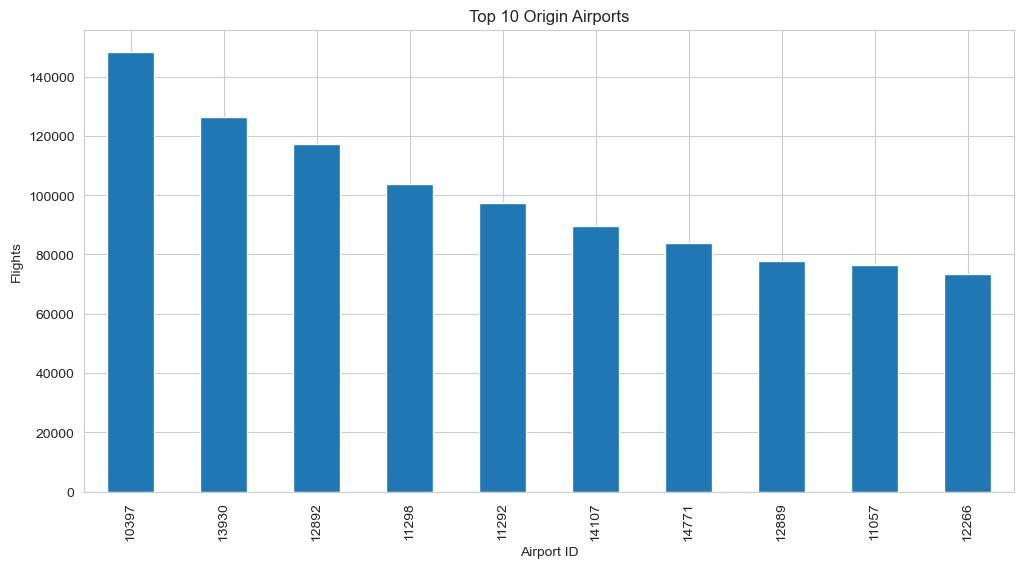

In [32]:
# 10. Top 10 Origin Airports
top_airports = df['OriginAirportID'].value_counts().head(10)

plt.figure(figsize=(12,6))
top_airports.plot(kind='bar')
plt.title("Top 10 Origin Airports")
plt.xlabel("Airport ID")
plt.ylabel("Flights")
plt.show()

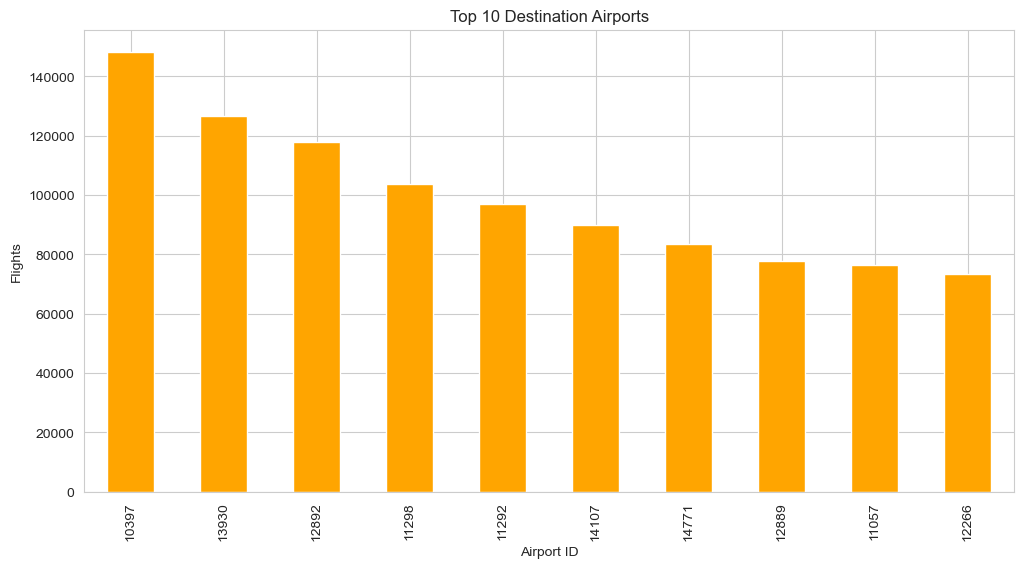

In [33]:
# 11. Top 10 Destination Airports
top_dest = df['DestAirportID'].value_counts().head(10)

plt.figure(figsize=(12,6))
top_dest.plot(kind='bar', color='orange')
plt.title("Top 10 Destination Airports")
plt.xlabel("Airport ID")
plt.ylabel("Flights")
plt.show()

In [37]:
import plotly.express as px

# 11. INTERACTIVE DEPARTURE DELAY GRAPH

fig = px.line(
    df.groupby('DayofMonth')['DepDelay'].mean().reset_index(),
    x='DayofMonth',
    y='DepDelay',
    title='Average Departure Delay by Day of Month',
    markers=True
)

fig.show()

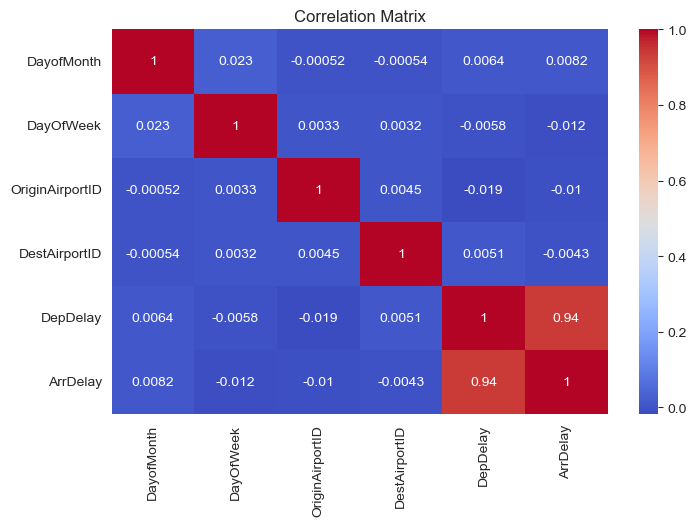

In [38]:
# 12. CORRELATION ANALYSIS
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [40]:
# MAXIMUM DEPARTURE DELAY

print("\nMaximum Departure Delay:")
print(df[df['DepDelay'] == df['DepDelay'].max()])


Maximum Departure Delay:
         DayofMonth  DayOfWeek Carrier  OriginAirportID  DestAirportID  \
2632902          15          2      AA            14107          13930   

         DepDelay  ArrDelay  
2632902      1863      1835  


In [41]:
# MINIMUM DEPARTURE DELAY

print("\nMinimum Departure Delay:")
print(df[df['DepDelay'] == df['DepDelay'].min()])


Minimum Departure Delay:
         DayofMonth  DayOfWeek Carrier  OriginAirportID  DestAirportID  \
2576772          11          5      F9            10821          14100   

         DepDelay  ArrDelay  
2576772       -63       -23  


In [42]:
# AVERAGE DEPARTURE DELAY BY CARRIER

print("\nAverage Departure Delay By Carrier:")
print(df.groupby('Carrier')['DepDelay'].mean())


Average Departure Delay By Carrier:
Carrier
9E     9.547171
AA    12.048700
AS     0.659362
B6    12.623111
DL     7.440828
EV    14.202467
F9    12.124133
FL    10.166287
HA     1.535419
MQ    15.203398
OO     7.853998
UA    12.564119
US     4.982806
VX    14.393710
WN    12.863348
YV     9.401597
Name: DepDelay, dtype: float64


In [43]:
# AVERAGE ARRIVAL DELAY BY CARRIER

print("\nAverage Arrival Delay By Carrier:")
print(df.groupby('Carrier')['ArrDelay'].mean())


Average Arrival Delay By Carrier:
Carrier
9E     4.807830
AA     7.161086
AS    -0.272154
B6     9.637322
DL     2.803831
EV    10.252738
F9    12.849424
FL     7.231183
HA     1.533180
MQ    13.870930
OO     6.361804
UA     5.171341
US     3.930652
VX     9.662913
WN     8.324426
YV     8.562012
Name: ArrDelay, dtype: float64


In [44]:
# TOP 10 MOST DELAYED FLIGHTS

print("\nTop 10 Highest Departure Delays:")

print(
    df[['Carrier', 'OriginAirportID', 'DestAirportID', 'DepDelay']]
    .sort_values(by='DepDelay', ascending=False)
    .head(10)
)


Top 10 Highest Departure Delays:
        Carrier  OriginAirportID  DestAirportID  DepDelay
2632902      AA            14107          13930      1863
1230689      HA            12889          12173      1847
1577611      AA            14869          11298      1620
2623263      AA            14100          13303      1487
2632909      AA            14107          13930      1481
900791       AA            15304          13930      1478
898846       AA            13487          13303      1446
101489       AA            10397          13303      1425
1591692      AA            14747          13303      1417
2629173      AA            10140          11298      1409


In [45]:
# BEST PERFORMING CARRIERS

best_carriers = df.groupby('Carrier')['ArrDelay'].mean().sort_values()

print("\nBest Performing Carriers:")
print(best_carriers.head())


Best Performing Carriers:
Carrier
AS   -0.272154
HA    1.533180
DL    2.803831
US    3.930652
9E    4.807830
Name: ArrDelay, dtype: float64
